# Gradient Clinic — 01 Healthy Network

Objetivo:
Construir una red neuronal pequeña, compararla contra un baseline
y observar loss, gradientes, calibración y comportamiento de inferencia.

Hipótesis:
Una MLP debería superar una regresión logística cuando los datos
contienen interacciones y relaciones no lineales.

### Importación de herramientas

Esta celda carga las bibliotecas que utilizaremos en el experimento:

- `random`: generador de números pseudoaleatorios de Python.
- `numpy as np`: creación de datos y operaciones sobre matrices.
- `pandas as pd`: organización del historial en tablas (`DataFrame`).
- `matplotlib.pyplot as plt`: gráficos de pérdidas y métricas.
- `torch` y `torch.nn as nn`: tensores, diferenciación automática, capas y función de pérdida.
- `TensorDataset` y `DataLoader`: asociación entre muestras y etiquetas, y procesamiento por lotes.
- `StandardScaler`: estandarización de las características.
- `LogisticRegression`: modelo de referencia para clasificación binaria.
- Las funciones de `sklearn.metrics`: evaluación del ordenamiento de predicciones y del error de las probabilidades.

`as` crea un alias corto; `from ... import ...` importa elementos concretos. Esta celda debe ejecutarse antes de las que utilizan esos nombres. Después de reiniciar el kernel, hay que volver a ejecutar las importaciones y las celdas que crean las variables.


In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

### Semillas y reproducibilidad

`SEED = 42` fija una semilla para los generadores de Python, NumPy y PyTorch. La semilla establece el estado inicial de una secuencia pseudoaleatoria; el número 42 no tiene una propiedad estadística especial.

- `random.seed(SEED)` configura el generador de Python.
- `np.random.seed(SEED)` controla los datos sintéticos, las etiquetas y la mezcla de índices de NumPy.
- `torch.manual_seed(SEED)` controla operaciones aleatorias de PyTorch, como la inicialización de parámetros y el Dropout.

Esto facilita repetir el experimento con el mismo orden de ejecución y entorno. No garantiza resultados idénticos entre todos los dispositivos, versiones y algoritmos. Reejecutar una celda aleatoria consume más números de la secuencia; para repetir el experimento desde el inicio, reinicia el kernel y ejecuta las celdas en orden.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Verificación de la semilla

`print("Seed:", SEED)` muestra el valor configurado. Es una comprobación visual del estado del experimento; no genera datos ni modifica el modelo. Si aparece `NameError`, la celda que define `SEED` no se ejecutó en el kernel actual.


In [3]:
print("Seed:", SEED)

Seed: 42


### Generación de la matriz de características

Se crean `N = 7000` muestras con `D = 20` características cada una:

$$X\in\mathbb{R}^{7000\times20},\qquad X_{ij}\sim\mathcal{N}(0,1).$$

`np.random.normal(size=(N, D))` usa por defecto media 0 y desviación estándar 1. Cada fila es una muestra y cada columna es una característica. `.astype(np.float32)` convierte el array a números de punto flotante de 32 bits, adecuados para el modelo de PyTorch que usaremos.

La distribución especificada tiene media 0 y desviación 1, pero las estadísticas de una muestra finita solo estarán aproximadamente cerca de esos valores.


In [4]:
N = 7000
D = 20

X = np.random.normal(size=(N, D)).astype(np.float32)

### Relación generadora: efectos lineales y no lineales

Para cada muestra se calcula un puntaje real $z_i$ que determinará su probabilidad de pertenecer a la clase positiva. Los subíndices siguientes corresponden a las columnas de Python, empezando en 0:

$$z_i=0.85x_{i,0}-0.65x_{i,1}+0.45x_{i,4}+1.10x_{i,2}x_{i,3}+0.95\sin(1.6x_{i,5})-0.55(x_{i,6}^2-1)-0.65.$$

- `X[:, j]` selecciona todas las filas de la columna `j`, y produce un vector de longitud 7000.
- Los tres primeros términos son efectos lineales.
- `X[:, 2] * X[:, 3]` es una interacción: el efecto de una variable depende del valor de la otra. `*` multiplica elemento a elemento.
- `np.sin(...)` introduce una relación no lineal periódica.
- `** 2` eleva al cuadrado; restar 1 centra este término en esperanza porque $E[X^2]=1$ para una normal estándar.
- El término constante $-0.65$ desplaza el puntaje hacia valores menores y afecta la proporción esperada de positivos.

Solo las columnas 0 a 6 intervienen directamente en la generación de las etiquetas; las restantes son características de ruido. Una regresión logística aplicada a las columnas originales no representa explícitamente estos productos, senos o cuadrados. La red podrá aproximarlos mediante capas no lineales, pero su superioridad debe comprobarse con evaluación.


In [5]:
z = (
    0.85 * X[:, 0]
    - 0.65 * X[:, 1]
    + 0.45 * X[:, 4]
    + 1.10 * X[:, 2] * X[:, 3]
    + 0.95 * np.sin(1.6 * X[:, 5])
    - 0.55 * (X[:, 6] ** 2 - 1)
    - 0.65
)

### Probabilidades y etiquetas de Bernoulli

La sigmoide convierte el puntaje en una probabilidad:

$$p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.$$

Un puntaje 0 produce una probabilidad 0.5; puntajes positivos elevan la probabilidad y negativos la reducen. `np.exp(-z)` aplica la exponencial a cada elemento.

Después, `np.random.rand(N)` genera valores $u_i$ uniformes en $[0,1)$, y la comparación genera etiquetas:

$$u_i\sim\mathcal{U}(0,1),\qquad y_i=\mathbf{1}[u_i<p_i],\qquad y_i\mid x_i\sim\operatorname{Bernoulli}(p_i).$$

`.astype(np.float32)` convierte `True` y `False` en 1.0 y 0.0. Una muestra con $p_i=0.8$ recibe la etiqueta 1 con probabilidad 80 %; no siempre recibe 1. Por eso existe incertidumbre irreducible en las etiquetas y no debemos esperar clasificación perfecta incluso con un buen modelo.


In [6]:
p = 1 / (1 + np.exp(-z))

y = (
    np.random.rand(N) < p
).astype(np.float32)

### Dimensiones y proporción de positivos

`X.shape` debería ser `(7000, 20)` y `y.shape`, `(7000,)`: hay una etiqueta por muestra. `shape` describe el tamaño de cada eje; no contiene los datos.

Como las etiquetas son binarias, su media es la proporción de positivos:

$$\widehat{\pi}=\frac{1}{N}\sum_{i=1}^N y_i.$$

`y.mean()` ayuda a detectar desequilibrio de clases. No es una métrica de calidad del modelo. La proporción observada puede variar entre conjuntos y realizaciones aleatorias.


In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive rate:", y.mean())

X shape: (7000, 20)
y shape: (7000,)
Positive rate: 0.39485714


### Partición aleatoria en entrenamiento, validación y prueba

`np.arange(N)` crea los índices de 0 a 6999. `np.random.shuffle(idx)` los mezcla **en el mismo array**, sin devolver uno nuevo.

Los tamaños elegidos son:

$$N_{\mathrm{train}}=4200,\qquad N_{\mathrm{val}}=1400,\qquad N_{\mathrm{test}}=1400.$$

Los cortes de Python incluyen el inicio y excluyen el final: `idx[:n_train]` toma los primeros 4200 índices; el siguiente tramo toma validación; el resto forma prueba. No se repiten muestras entre esos tramos.

Entrenamiento permite ajustar parámetros; validación permite observar generalización y tomar decisiones; prueba sirve para una evaluación final después de esas decisiones. Esta partición es aleatoria, pero no estratificada: no obliga a conservar exactamente la proporción de clases en cada conjunto.


In [8]:
idx = np.arange(N)
np.random.shuffle(idx)

n_train = int(0.60 * N)
n_val = int(0.20 * N)

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train+n_val]
test_idx = idx[n_train+n_val:]

### Separación de características y etiquetas

`X[train_idx]` selecciona filas mediante un array de índices. Se aplica el mismo índice a `X` y `y` para conservar la correspondencia entre cada muestra y su etiqueta:

$$\mathcal{D}_{\mathrm{train}}=\{(x_i,y_i):i\in I_{\mathrm{train}}\}.$$

Se repite la operación para validación y prueba. Mezclar las características y las etiquetas por separado rompería esa correspondencia y haría que el modelo aprendiera con etiquetas incorrectas.


In [9]:
X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

### Comprobación del tamaño de las particiones

Se imprimen las formas esperadas: entrenamiento `(4200, 20)`, validación `(1400, 20)` y prueba `(1400, 20)`.

`shape[0]` es el número de muestras y `shape[1]`, el número de características. Las particiones deben conservar las mismas 20 columnas para que el modelo pueda procesarlas con la misma arquitectura.


In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4200, 20)
(1400, 20)
(1400, 20)


### Estandarización sin fuga de información

`StandardScaler` transforma cada columna utilizando la media y la desviación estándar calculadas **solo con entrenamiento**:

$$\mu_j=\frac{1}{n}\sum_{i=1}^{n}x_{ij},\qquad s_j=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\mu_j)^2},\qquad \widetilde{x}_{ij}=\frac{x_{ij}-\mu_j}{s_j}.$$

- `fit_transform(X_train)` aprende las estadísticas y transforma el entrenamiento.
- `transform(X_val)` y `transform(X_test)` aplican esas mismas estadísticas sin volver a ajustarlas.

Esto evita que la preparación del modelo incorpore información de validación o prueba. La escala comparable entre características puede facilitar la optimización. Aunque los datos originales vienen de una normal estándar, las estadísticas empíricas del entrenamiento no son exactamente 0 y 1.

Las asignaciones reemplazan las variables originales por sus versiones estandarizadas. Para nuevas muestras, habrá que reutilizar este mismo `scaler`; el modelo por sí solo no guarda la transformación.


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Verificación de la estandarización

`mean(axis=0)` y `std(axis=0)` calculan una estadística por columna recorriendo las filas. `[:5]` muestra solo las primeras cinco características.

Después de estandarizar el entrenamiento, deberíamos observar:

$$\operatorname{media}(\widetilde{X}_{\mathrm{train},j})\approx0,\qquad\operatorname{std}(\widetilde{X}_{\mathrm{train},j})\approx1.$$

Las pequeñas diferencias se deben al cálculo en punto flotante. No se exige que validación y prueba tengan exactamente estas estadísticas, porque se transforman usando las del entrenamiento.


In [12]:
print(
    X_train.mean(axis=0)[:5]
)

print(
    X_train.std(axis=0)[:5]
)

[-6.0810930e-09 -1.3428785e-09 -1.6916365e-08  5.7688783e-09
  9.4515933e-09]
[0.9999993  0.9999997  0.99999994 1.0000001  1.0000001 ]


### Regresión logística como modelo de referencia

La regresión logística aprende una probabilidad a partir de una combinación lineal:

$$\widehat p_i=\sigma(w^T\widetilde{x}_i+b).$$

`baseline.fit(X_train, y_train)` ajusta sus parámetros. `max_iter=1500` establece el máximo de iteraciones del algoritmo de optimización; no equivale a 1500 épocas de la red. La configuración por defecto también puede aplicar regularización.

`predict_proba(X_test)` devuelve una columna por clase. Para las etiquetas 0 y 1 de este experimento, `[:, 1]` extrae la probabilidad de la clase 1 y produce un vector de longitud 1400.

Este modelo proporciona una referencia sencilla. Su frontera en las características originales es lineal, mientras que la relación generadora incluye interacciones y otras funciones no lineales. Aquí se predice sobre **prueba**; la red se evaluará más adelante sobre **validación**, así que esas cifras no constituyen una comparación directa sobre las mismas muestras.


In [13]:
baseline = LogisticRegression(max_iter=1500)

baseline.fit(X_train, y_train)

p_baseline = baseline.predict_proba(X_test)[:, 1]

### Métricas del modelo de referencia

Se comparan las probabilidades del baseline con las etiquetas de prueba. No es necesario convertirlas a clases con un umbral.

**ROC-AUC.** Resume la curva de tasa de verdaderos positivos frente a tasa de falsos positivos:

$$\mathrm{TPR}=\frac{TP}{TP+FN},\qquad\mathrm{FPR}=\frac{FP}{FP+TN}.$$

La AUC equivale a la probabilidad de que un positivo reciba una puntuación mayor que un negativo, contando empates con peso 0.5. Valores mayores son mejores; 0.5 corresponde a un ordenamiento aleatorio.

**Average precision (AP).** `average_precision_score` resume precisión y recall mediante incrementos de recall:

$$\mathrm{Precision}=\frac{TP}{TP+FP},\qquad\mathrm{Recall}=\frac{TP}{TP+FN},\qquad\mathrm{AP}=\sum_k(R_k-R_{k-1})P_k.$$

El código la etiqueta como `PR-AUC`, pero AP no es exactamente la integración trapezoidal de la curva precisión-recall. Valores mayores son mejores y su referencia depende de la proporción de positivos.

**Brier.** Evalúa el error cuadrático de las probabilidades:

$$\mathrm{BS}=\frac{1}{n}\sum_{i=1}^{n}(\widehat p_i-y_i)^2.$$

Valores menores son mejores. Para etiquetas binarias y probabilidades entre 0 y 1, está entre 0 y 1. Refleja calidad probabilística, incluyendo aspectos de calibración y discriminación; no es una medida exclusiva de calibración. ROC-AUC y AP evalúan ordenamiento, por lo que valores altos no garantizan probabilidades bien calibradas.


In [14]:
baseline_auc = roc_auc_score(
    y_test,
    p_baseline
)

baseline_pr = average_precision_score(
    y_test,
    p_baseline
)

baseline_brier = brier_score_loss(
    y_test,
    p_baseline
)

print("ROC-AUC:", baseline_auc)
print("PR-AUC:", baseline_pr)
print("Brier:", baseline_brier)

ROC-AUC: 0.7368016626747917
PR-AUC: 0.6194861729393802
Brier: 0.20034466683864594


### Arquitectura de la red neuronal

`TinyNet` hereda de `nn.Module`, la clase base de los modelos de PyTorch. `super().__init__()` inicializa sus mecanismos de registro de capas y parámetros. `nn.Sequential` ejecuta las capas en el orden declarado.

Para un lote de tamaño $B$, las dimensiones recorren:

$$ (B,20)\longrightarrow(B,64)\longrightarrow(B,32)\longrightarrow(B,1)\longrightarrow(B).$$

**Capas lineales.** `nn.Linear(a, b)` aprende una matriz de pesos y un sesgo, aplicando $h=Wx+b$. Con 20 entradas, las capas son 20→64, 64→32 y 32→1.

**BatchNorm.** `nn.BatchNorm1d(64)` normaliza cada activación usando estadísticas del lote durante entrenamiento y aprende escala y desplazamiento:

$$\widehat h_j=\frac{h_j-\mu_{B,j}}{\sqrt{\sigma_{B,j}^2+\epsilon}},\qquad h'_j=\gamma_j\widehat h_j+\beta_j.$$

Durante evaluación utiliza estadísticas acumuladas. El término $\epsilon$ evita una división inestable cuando la varianza es pequeña.

**ReLU.** `nn.ReLU()` aplica $\operatorname{ReLU}(a)=\max(0,a)$. Introduce no linealidad; una composición de capas puramente lineales seguiría siendo una transformación afín.

**Dropout.** Durante entrenamiento, para probabilidad de descarte $q$:

$$\widetilde h_j=\frac{m_jh_j}{1-q},\qquad m_j\sim\operatorname{Bernoulli}(1-q).$$

`Dropout(0.20)` descarta aproximadamente el 20 % de activaciones y `Dropout(0.10)`, el 10 %. El reescalado conserva su valor esperado. En evaluación no las descarta. Es una forma de regularización, sin garantía de eliminar el sobreajuste.

`forward` define la propagación hacia delante. La última capa devuelve logits, sin sigmoide, porque la pérdida la incorporará internamente. `.squeeze(1)` elimina exclusivamente el eje 1 de tamaño 1 y hace compatible la salida `(B,)` con las etiquetas. Esta celda define la clase; todavía no crea una instancia del modelo.


In [15]:
class TinyNet(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Creación de la instancia del modelo

`X_train.shape[1]` devuelve el número de columnas: 20. Al pasarlo a `TinyNet`, la primera capa acepta exactamente esas características.

Crear `model` inicializa los pesos y sesgos y registra los parámetros entrenables. `print(model)` muestra la arquitectura, pero no entrena la red. Una instancia nueva empieza en modo entrenamiento; volver a ejecutar esta celda crea otro modelo y pierde los parámetros aprendidos en la variable anterior. Si ya existe un optimizador, también habría que recrearlo para asociarlo a los nuevos parámetros.


In [16]:
model = TinyNet(
    X_train.shape[1]
)

print(model)

TinyNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Primer lote de prueba como tensor

`X_train[:32]` selecciona las filas con índices 0 a 31 y conserva todas las columnas. `torch.tensor(..., dtype=torch.float32)` copia esos datos en un tensor de 32 bits:

$$x_b\in\mathbb{R}^{32\times20}.$$

Este lote pequeño permite revisar el flujo del modelo antes de entrenar. No cambia el tamaño del entrenamiento completo ni define el tamaño del `DataLoader` posterior. Las entradas no necesitan `requires_grad=True` para calcular los gradientes de los parámetros del modelo.


In [17]:
xb = torch.tensor(
    X_train[:32],
    dtype=torch.float32
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Propagación hacia delante e inspección de logits

`model(xb)` ejecuta el método `forward` mediante la interfaz de `nn.Module`. Devuelve un logit por muestra: `logits.shape` debería ser `(32,)`. `logits[:5]` muestra los primeros cinco valores.

Un logit $z$ está relacionado con la probabilidad por:

$$p=\sigma(z),\qquad z=\log\frac{p}{1-p}.$$

Los logits pueden ser negativos o mayores que 1; no son probabilidades. La red aún no está entrenada. En modo entrenamiento, Dropout puede hacer que repetir la predicción produzca otros valores, y BatchNorm actualiza sus estadísticas acumuladas incluso si todavía no se actualizan los pesos con un optimizador.


In [18]:
logits = model(xb)

print(logits.shape)
print(logits[:5])

torch.Size([32])
tensor([ 0.0645, -0.1756, -0.0669,  0.0132, -0.6229], grad_fn=<SliceBackward0>)


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Comprobación de estabilidad numérica

`torch.isfinite(logits)` devuelve un booleano por elemento: es verdadero si el valor no es `NaN` ni infinito. `.all()` exige que todos sean finitos; `assert` genera un `AssertionError` si la condición falla.

$$\forall i:\quad z_i\in\mathbb{R}\text{ y es finito}.$$

Es una revisión rápida de estabilidad numérica. Pasarla no demuestra que el modelo sea correcto o esté aprendiendo; solo descarta estos valores inválidos en la salida inspeccionada.


In [19]:
assert torch.isfinite(
    logits
).all()

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Etiquetas del lote de prueba

`y_train[:32]` selecciona las etiquetas de las mismas primeras 32 muestras usadas en `xb`. Su conversión a `torch.float32` produce un tensor de forma `(32,)` con valores 0.0 o 1.0.

`BCEWithLogitsLoss` espera objetivos de punto flotante y la misma forma que los logits. La coincidencia de índices entre `xb` y `yb` es indispensable: cada predicción debe compararse con su propia etiqueta.


In [20]:
yb = torch.tensor(
    y_train[:32],
    dtype=torch.float32
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Entropía cruzada binaria sobre logits

`nn.BCEWithLogitsLoss()` crea la función de pérdida para clasificación binaria. Por defecto devuelve la media del lote:

$$\mathcal{L}=\frac{1}{B}\sum_{i=1}^B\left[-y_i\log\sigma(z_i)-(1-y_i)\log(1-\sigma(z_i))\right].$$

Internamente combina sigmoide y entropía cruzada usando una formulación estable, equivalente por muestra a:

$$\ell(z,y)=\max(z,0)-yz+\log(1+e^{-|z|}).$$

Debemos pasar **logits directamente**, sin aplicar una sigmoide antes. Para inferencia sí aplicaremos sigmoide para obtener probabilidades. La derivada por logit de la pérdida media es:

$$\frac{\partial\mathcal{L}}{\partial z_i}=\frac{\sigma(z_i)-y_i}{B}.$$

Esta diferencia entre probabilidad y etiqueta inicia la señal que se propagará hacia las capas anteriores.


In [21]:
loss_fn = nn.BCEWithLogitsLoss()

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Cálculo inicial de la pérdida

Se obtiene una nueva salida de la red y se calcula `loss_fn(logits, yb)`. El resultado es un tensor escalar: la pérdida promedio de las 32 muestras.

Una predicción constante de 0.5 produce una pérdida $-\log(0.5)\approx0.693$, útil como referencia orientativa. No es un valor que todo modelo inicial deba tener, ni la mejor referencia constante para cualquier proporción de clases.

`print(loss)` puede mostrar información del grafo de diferenciación (`grad_fn`). Aquí solo se mide el error: no se llama a `backward()` ni a `optimizer.step()`, por lo que no se ajustan los parámetros.


In [22]:
logits = model(xb)

loss = loss_fn(
    logits,
    yb
)

print(loss)

tensor(0.7069, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Retropropagación y cálculo de gradientes

`model.zero_grad()` limpia los gradientes de los parámetros. Luego se realiza una nueva propagación, se calcula la pérdida y `loss.backward()` aplica diferenciación automática y la regla de la cadena:

$$\nabla_\theta\mathcal{L}=\left(\frac{\partial\mathcal{L}}{\partial\theta_1},\ldots,\frac{\partial\mathcal{L}}{\partial\theta_P}\right).$$

Para un parámetro que influye sobre logits intermedios, la idea es:

$$\frac{\partial\mathcal{L}}{\partial\theta_j}=\sum_i\frac{\partial\mathcal{L}}{\partial z_i}\frac{\partial z_i}{\partial\theta_j}.$$

PyTorch guarda el resultado en `.grad` de cada parámetro participante. Los gradientes se acumulan entre llamadas a `backward()` si no se limpian; por eso el borrado es necesario. Esta celda calcula gradientes, pero todavía no actualiza los parámetros: eso requiere un paso del optimizador.


In [23]:
model.zero_grad()

logits = model(xb)

loss = loss_fn(
    logits,
    yb
)

loss.backward()

### Inspección de gradientes por parámetro

`model.named_parameters()` devuelve pares `(nombre, parámetro)`, incluidos pesos, sesgos y parámetros aprendibles de BatchNorm. La condición `parameter.grad is not None` evita operar sobre parámetros sin gradiente calculado.

`parameter.grad.norm()` obtiene la norma L2, considerando todos los elementos del tensor:

$$\|g^{(k)}\|_2=\sqrt{\sum_j(g_j^{(k)})^2}.$$

`.item()` convierte el tensor escalar a un número de Python para imprimirlo. Esto permite localizar señales muy pequeñas o grandes en grupos de parámetros. Las normas dependen también del tamaño de cada grupo: no son directamente comparables como si todos tuvieran el mismo número de elementos. Un gradiente cero en una inspección no prueba por sí solo un fallo de entrenamiento.


In [24]:
for name, parameter in model.named_parameters():

    if parameter.grad is not None:

        print(
            name,
            parameter.grad.norm().item()
        )

network.0.weight 0.14438606798648834
network.0.bias 2.9830449221890376e-09
network.1.weight 0.02156550996005535
network.1.bias 0.020700499415397644
network.4.weight 0.2721559703350067
network.4.bias 0.04614168778061867
network.7.weight 0.14836913347244263
network.7.bias 0.11179564148187637


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Definición de la norma global del gradiente

La función recorre todos los parámetros con gradiente, suma los cuadrados de sus elementos y toma la raíz al final:

$$\|\nabla_\theta\mathcal{L}\|_2=\sqrt{\sum_k\sum_j\left(g_j^{(k)}\right)^2}.$$

- `.detach()` separa el gradiente del seguimiento de diferenciación: esta medición es un diagnóstico.
- `.pow(2)` eleva cada componente al cuadrado.
- `.sum()` suma los cuadrados del tensor.
- `.item()` extrae el escalar para acumularlo en Python.
- `total ** 0.5` calcula la raíz cuadrada.

Se calcula la norma del vector formado por **todos** los gradientes; no se suman las normas de las capas. Esta función no modifica, normaliza ni recorta los gradientes. Si no hay ninguno disponible, devuelve 0. Definir la función no la ejecuta aún.


In [25]:
def gradient_norm(model):

    total = 0.0

    for parameter in model.parameters():

        if parameter.grad is not None:

            total += (
                parameter.grad
                .detach()
                .pow(2)
                .sum()
                .item()
            )

    return total ** 0.5

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Medición del gradiente global actual

`gradient_norm(model)` mide los gradientes existentes, calculados en la última retropropagación. No genera una nueva predicción ni recalcula la pérdida.

La norma resume la magnitud global de la señal de actualización, pero no determina por sí sola la salud de la red. Su interpretación depende de la arquitectura, la escala de la pérdida, el tamaño del lote y el optimizador. Adam adapta las actualizaciones, así que esta norma no es directamente la magnitud del cambio de parámetros.


In [26]:
print(
    gradient_norm(model)
)

0.36393749788367175


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Construcción del conjunto de entrenamiento de PyTorch

Se convierten las 4200 muestras y sus etiquetas a tensores `float32` y se agrupan con `TensorDataset`:

$$X_{\mathrm{train}}\in\mathbb{R}^{4200\times20},\qquad y_{\mathrm{train}}\in\{0,1\}^{4200}.$$

Cada acceso `train_dataset[i]` devuelve el par `(X_train_tensor[i], y_train_tensor[i])`. Ambos tensores deben tener el mismo tamaño en su primer eje. El dataset organiza los datos; no los mezcla ni entrena el modelo.


In [27]:
train_dataset = TensorDataset(

    torch.tensor(
        X_train,
        dtype=torch.float32
    ),

    torch.tensor(
        y_train,
        dtype=torch.float32
    )
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Lotes y mezcla con DataLoader

`DataLoader` recorre el dataset en lotes de hasta 128 muestras. `shuffle=True` cambia el orden al crear un nuevo recorrido, conservando cada muestra junto a su etiqueta.

$$\#\text{lotes por época}=\left\lceil\frac{4200}{128}\right\rceil=33.$$

Como `drop_last` es falso por defecto, hay 32 lotes de 128 y uno de 104. El gradiente de cada lote aproxima el gradiente del conjunto completo:

$$g_B=\frac{1}{|B|}\sum_{i\in B}\nabla_\theta\ell_i.$$

Esto permite actualizar varias veces por época con menos datos por paso. La mezcla reduce la dependencia del orden original. El tamaño del lote también afecta la variabilidad del gradiente y las estadísticas de BatchNorm.


In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Inspección de un lote del DataLoader

`iter(train_loader)` crea un iterador y `next(...)` obtiene su primer lote. La asignación `xb, yb` separa características y etiquetas.

Las dimensiones esperadas son `(128, 20)` y `(128,)`. Estas variables reemplazan el lote de 32 muestras usado antes. Crear este iterador participa en la secuencia aleatoria de mezcla; el posterior bucle de entrenamiento crea su propio recorrido y no continúa este iterador de inspección.


In [29]:
xb, yb = next(
    iter(train_loader)
)

print(xb.shape)
print(yb.shape)

torch.Size([128, 20])
torch.Size([128])


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Optimizador Adam y tasa de aprendizaje

`torch.optim.Adam(model.parameters(), lr=1e-3)` asocia el optimizador a los parámetros actuales de la red. `1e-3` es 0.001, la tasa de aprendizaje $\eta$.

Adam mantiene promedios móviles del gradiente y de su cuadrado:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\qquad v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2.$$

Tras corregir el sesgo inicial:

$$\widehat m_t=\frac{m_t}{1-\beta_1^t},\qquad\widehat v_t=\frac{v_t}{1-\beta_2^t},\qquad\theta_t=\theta_{t-1}-\eta\frac{\widehat m_t}{\sqrt{\widehat v_t}+\epsilon}.$$

Las operaciones se aplican por componente. Adam adapta la escala de actualización según el historial de gradientes. Crear el optimizador todavía no modifica los pesos; `optimizer.step()` realiza el cambio. Si se crea otra instancia de `model`, hay que crear un optimizador asociado a ella.


In [30]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Entrenamiento, validación y registro durante 30 épocas

Se preparan tensores de validación, una lista vacía `history` y 30 épocas. Una época es un recorrido completo del entrenamiento; con 33 lotes por época habrá 990 pasos del optimizador en esta ejecución.

**Entrenamiento de cada época.** `model.train()` activa Dropout y el uso de estadísticas de lote en BatchNorm. Para cada par `xb, yb`:

1. `optimizer.zero_grad()` limpia la señal de la iteración anterior.
2. `model(xb)` calcula logits.
3. `loss_fn(logits, yb)` calcula la pérdida media del lote.
4. `loss.backward()` calcula gradientes.
5. `gradient_norm(model)` registra su norma antes de actualizar parámetros.
6. `optimizer.step()` aplica la actualización de Adam.
7. `.item()` permite almacenar la pérdida como un número de Python.

**Validación de cada época.** `model.eval()` desactiva Dropout y cambia BatchNorm a sus estadísticas acumuladas. `torch.no_grad()` evita construir el grafo de diferenciación. Son mecanismos distintos y se necesitan ambos para este uso. La validación calcula pérdida sobre las 1400 muestras, aplica sigmoide y obtiene AP y ROC-AUC. No llama a `backward()` ni al optimizador con estos datos.

**Registro.** `history.append({...})` guarda el número de época, pérdida de entrenamiento, pérdida de validación, norma media del gradiente, AP de validación (llamada `val_pr_auc`) y ROC-AUC de validación.

La pérdida registrada de entrenamiento es:

$$\overline{\mathcal{L}}_{\mathrm{train}}=\frac{1}{K}\sum_{b=1}^{K}\mathcal{L}_b.$$

Es una media **por lote**, no una media ponderada por muestra: el lote final de 104 recibe el mismo peso que los de 128. Además, esos lotes se evalúan mientras cambian los parámetros y con Dropout activo; la pérdida de validación usa el modelo al final de la época y modo evaluación. Por eso las dos curvas no son medidas bajo condiciones idénticas.

Si la pérdida de entrenamiento baja mientras la de validación sube de forma sostenida, puede haber sobreajuste. Este código no implementa parada temprana ni selecciona el mejor modelo: conserva el de la época 30. Reejecutarlo vacía `history`, pero sigue entrenando el modelo y optimizador existentes, salvo que también se recreen.


In [31]:
X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

history = []

epochs = 30

for epoch in range(epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    train_losses = []
    gradient_norms = []

    for xb, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb)

        loss = loss_fn(
            logits,
            yb
        )

        loss.backward()

        grad_norm = gradient_norm(model)

        optimizer.step()

        train_losses.append(
            loss.item()
        )

        gradient_norms.append(
            grad_norm
        )

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(
            X_val_tensor
        )

        val_loss = loss_fn(
            val_logits,
            y_val_tensor
        )

        val_prob = torch.sigmoid(
            val_logits
        ).numpy()

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    # -------------------------
    # REGISTRO
    # -------------------------
    history.append({
        "epoch": epoch + 1,
        "train_loss": np.mean(train_losses),
        "val_loss": val_loss.item(),
        "gradient_norm": np.mean(gradient_norms),
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc
    })

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Tabla del historial del experimento

`pd.DataFrame(history)` convierte la lista de diccionarios en una tabla: cada fila representa una época y cada clave se convierte en una columna.

La expresión final `history_df` hace que Jupyter muestre la tabla, aunque la visualización puede truncarse según la configuración de pandas. Sirve para relacionar pérdida, generalización y gradientes en la misma época. No vuelve a entrenar ni recalcula las métricas.


In [32]:
history_df = pd.DataFrame(
    history
)

history_df

,epoch,train_loss,val_loss,gradient_norm,val_pr_auc,val_roc_auc
0,1,0.663346,0.639989,0.212794,0.588966,0.695078
1,2,0.624293,0.601098,0.214644,0.641501,0.738866
2,3,0.599109,0.576009,0.255809,0.663589,0.756281
3,4,0.581894,0.565788,0.274720,0.677199,0.767014
4,5,0.572169,0.556360,0.279818,0.687023,0.776427
5,6,0.564386,0.550456,0.293044,0.702705,0.786335
6,7,0.554588,0.539384,0.308493,0.714889,0.795747
7,8,0.543286,0.533733,0.327363,0.724373,0.803411
8,9,0.541517,0.523041,0.327005,0.729929,0.811248
9,10,0.527499,0.515906,0.341158,0.739106,0.816291


### Comparación gráfica de pérdidas de entrenamiento y validación

`plt.figure(figsize=(8, 5))` crea una figura de 8 por 5 pulgadas. Cada `plt.plot` dibuja una serie frente al número de época; `label` define su nombre y `plt.legend()` muestra la leyenda. `xlabel`, `ylabel` y `title` describen el gráfico; `show()` lo presenta.

Ambas series usan entropía cruzada binaria. Una pérdida de entrenamiento descendente sugiere ajuste a los datos. Una pérdida de validación que primero baja y luego aumenta puede indicar sobreajuste. Si ambas se estancan en valores altos, conviene revisar capacidad, datos y optimización.

La pérdida de validación puede ser menor que la de entrenamiento porque en evaluación no se aplica Dropout y porque las pérdidas de entrenamiento se midieron mientras el modelo se actualizaba. Una separación entre curvas no demuestra por sí sola un problema. Esta celda muestra la figura, pero no la guarda en un archivo.


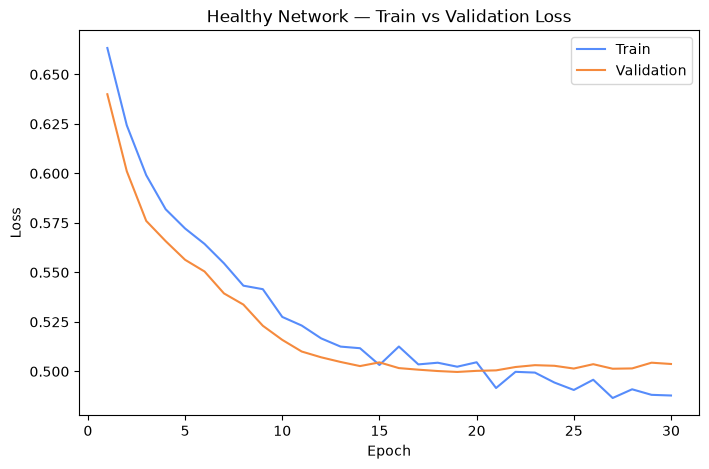

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Healthy Network — Train vs Validation Loss")

plt.legend()
plt.show()

### Inspección de las últimas épocas

`history_df.tail()` muestra las últimas cinco filas por defecto. Permite revisar los valores finales de pérdida, gradientes y métricas sin recorrer toda la tabla.

Las últimas épocas no necesariamente contienen el mejor resultado de validación. El notebook mantiene el estado final del modelo y no recupera automáticamente la época con menor pérdida de validación.


In [34]:
history_df.tail()

,epoch,train_loss,val_loss,gradient_norm,val_pr_auc,val_roc_auc
25,26,0.495771,0.503627,0.388954,0.748906,0.823370
26,27,0.486551,0.501334,0.365512,0.749301,0.825117
27,28,0.490948,0.501492,0.381488,0.747901,0.824795
28,29,0.488146,0.504381,0.393217,0.748768,0.823223
29,30,0.487813,0.503731,0.389604,0.748139,0.823428


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Dinámica de la norma del gradiente

Se representa la norma L2 global promedio de los lotes de cada época:

$$\overline G_e=\frac{1}{K}\sum_{b=1}^{K}\|\nabla_\theta\mathcal{L}_{e,b}\|_2.$$

Esto es la **media de normas**, que no equivale a la norma de la media de gradientes. `plt.yscale("log")` usa una escala logarítmica: distancias iguales representan factores multiplicativos, por ejemplo 0.01→0.1→1.

Picos pronunciados pueden motivar una revisión de estabilidad; gradientes pequeños junto con ausencia de aprendizaje pueden motivar una revisión de la propagación de señal. No hay un umbral universal que diagnostique explosión o desvanecimiento, y la media puede ocultar picos de lotes o diferencias entre capas. El cero no tiene representación finita en una escala logarítmica. Este gráfico no aplica recorte de gradientes.


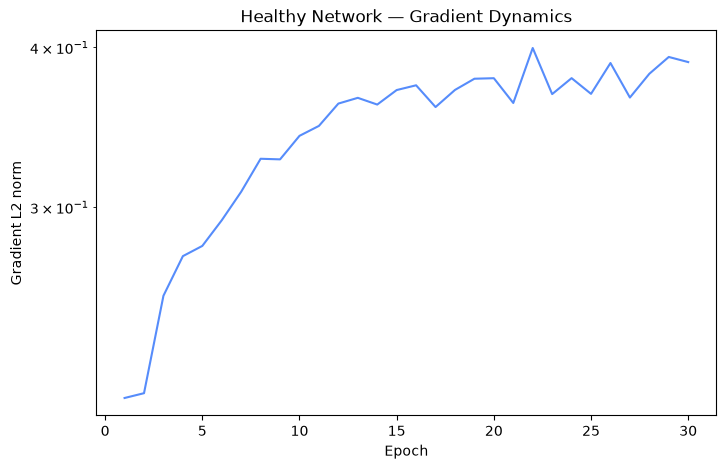

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["gradient_norm"]
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Gradient L2 norm")

plt.title("Healthy Network — Gradient Dynamics")

plt.show()

### Evolución de average precision en validación

Se dibuja `val_pr_auc` por época. Aunque los nombres del código y del eje dicen `PR-AUC`, el valor proviene de `average_precision_score`, es decir, **average precision (AP)**:

$$\mathrm{AP}=\sum_k(R_k-R_{k-1})P_k.$$

Valores mayores indican mejor relación entre precisión y recall al variar el umbral. La prevalencia de positivos afecta la interpretación; como referencia de ordenamiento aleatorio suele usarse la proporción de positivos del conjunto evaluado.

La AP mide ordenamiento y la pérdida también considera los valores de las probabilidades, así que no tienen por qué mejorar exactamente al mismo ritmo. Si se usa esta curva para elegir arquitectura o época, la estimación final debería realizarse en un conjunto de prueba reservado.


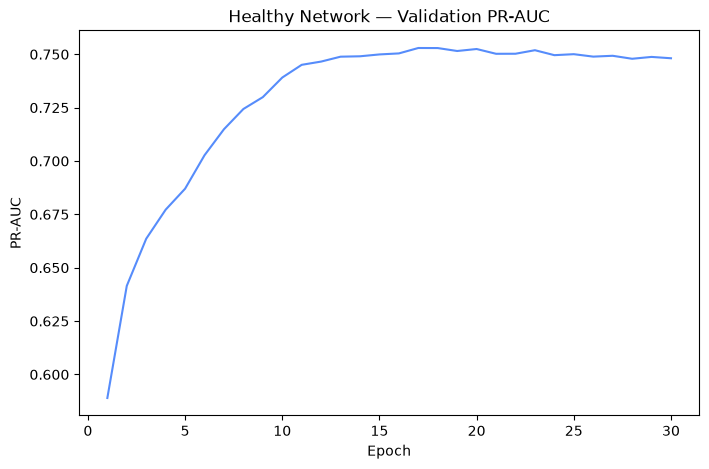

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_pr_auc"]
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")

plt.title("Healthy Network — Validation PR-AUC")

plt.show()

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Exportación del historial a CSV

`history_df.to_csv(..., index=False)` guarda las métricas en `../outputs/metrics/healthy_run.csv`. `index=False` evita añadir una columna extra con el índice de pandas.

La ruta es relativa al **directorio de trabajo del kernel**, no necesariamente al archivo del notebook. Si el kernel trabaja desde `notebooks/`, apunta a la carpeta `outputs/metrics/` del proyecto. La carpeta debe existir; pandas no la crea automáticamente. Si el archivo ya existe, esta llamada lo sobrescribe.

El CSV conserva métricas para analizarlas después, pero no los parámetros del modelo, las estadísticas del escalador ni el estado del optimizador.


In [37]:
history_df.to_csv(
    "../outputs/metrics/healthy_run.csv",
    index=False
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Guardado de los parámetros aprendidos

`model.state_dict()` devuelve los parámetros y buffers registrados de la red, incluidos pesos, sesgos y estadísticas acumuladas de BatchNorm. `torch.save` los guarda en `../outputs/models/healthy_model.pt`.

La ruta depende del directorio de trabajo del kernel y su carpeta debe existir. Un archivo con el mismo nombre se sobrescribe. Se guarda el modelo de la última época, no necesariamente el mejor según validación.

Este archivo no incluye la definición de `TinyNet`, el `StandardScaler`, el estado de Adam ni el historial. Para inferencia habrá que reconstruir la misma arquitectura, cargar sus parámetros, aplicar el escalador ajustado en entrenamiento y usar `eval()`. Para reanudar exactamente el entrenamiento también haría falta guardar el estado del optimizador y otra información del experimento.


In [38]:
torch.save(
    model.state_dict(),
    "../outputs/models/healthy_model.pt"
)

### Preparación para inferencia en validación

`model.eval()` establece el modo evaluación: Dropout deja de descartar activaciones y BatchNorm utiliza sus estadísticas acumuladas. No congela parámetros ni desactiva por sí mismo el cálculo de gradientes.

`torch.tensor(X_val, dtype=torch.float32)` crea `Xv` con forma `(1400, 20)`. Son los datos de validación ya estandarizados. En este notebook el modelo y los tensores se usan en CPU; si se trasladara el modelo a otro dispositivo, sus entradas también tendrían que trasladarse.


In [39]:
model.eval()

Xv = torch.tensor(
    X_val,
    dtype=torch.float32
)

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Conversión de logits a probabilidades de validación

Dentro de `torch.no_grad()` se ejecuta el modelo sin registrar operaciones para retropropagación, reduciendo el uso de memoria asociado al grafo.

$$z_i=f_\theta(\widetilde x_i),\qquad\widehat p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.$$

`torch.sigmoid(logits)` convierte los 1400 logits en probabilidades de clase 1. `.numpy()` las convierte a un array compatible con scikit-learn. Funciona aquí porque el tensor está en CPU y no requiere gradientes dentro de este bloque; en GPU habría que moverlo antes a CPU.

No se aplica un umbral de 0.5: las métricas posteriores utilizan probabilidades. Si se necesitaran etiquetas predichas, se podría usar $\widehat y_i=\mathbf{1}[\widehat p_i\geq\tau]$, eligiendo $\tau$ según el propósito de la clasificación.


In [40]:
with torch.no_grad():

    logits = model(Xv)

    p_val = torch.sigmoid(
        logits
    ).numpy()

### Celda vacía de separación

La siguiente celda no contiene instrucciones ejecutables. No calcula valores ni modifica datos, parámetros o métricas; se conserva como espacio para notas o futuras pruebas. No requiere fundamento matemático.


### Evaluación probabilística final de la red en validación

Se comparan `p_val` y `y_val`, que tienen una probabilidad y una etiqueta por muestra. Se calculan ROC-AUC, average precision (impresa como `PR-AUC`) y Brier:

$$\mathrm{AP}=\sum_k(R_k-R_{k-1})P_k,\qquad\mathrm{Brier}=\frac{1}{n_{\mathrm{val}}}\sum_i(\widehat p_i-y_i)^2.$$

ROC-AUC y AP deben ser mayores para indicar mejor ordenamiento; Brier debe ser menor para indicar menor error probabilístico. Ninguna métrica aislada demuestra que el modelo sea adecuado en todos los aspectos. Para estudiar calibración con más detalle se puede complementar Brier con una curva de confiabilidad que compare probabilidades predichas y frecuencias observadas.

Esta evaluación corresponde al modelo final en **validación**. El baseline anterior se midió en **prueba**: para comprobar la hipótesis de superioridad, ambos deben evaluarse sobre las mismas muestras, idealmente el conjunto de prueba después de cerrar las decisiones basadas en validación. La celda actual no realiza esa comparación ni evalúa la red sobre `X_test`.


In [41]:
val_auc = roc_auc_score(
    y_val,
    p_val
)

val_pr = average_precision_score(
    y_val,
    p_val
)

val_brier = brier_score_loss(
    y_val,
    p_val
)

print("Validation ROC-AUC:", val_auc)
print("Validation PR-AUC:", val_pr)
print("Validation Brier:", val_brier)

Validation ROC-AUC: 0.8234276853307354
Validation PR-AUC: 0.748139377742741
Validation Brier: 0.1660335659980774
